In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive



# Import

In [ ]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout
from tensorflow.keras.preprocessing.image import ImageDataGenerator

import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report

In [ ]:
BASE_DIR = "/content/drive/MyDrive/ModelAI_DesaSengka/dataset/Tomato"
train_dir = BASE_DIR + "/train"
val_dir = BASE_DIR + "/validation"
test_dir = BASE_DIR + "/test"

# Preproccesing

In [ ]:
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    zoom_range=0.2,
    horizontal_flip=True
)

val_datagen = ImageDataGenerator(rescale=1./255)

test_datagen = ImageDataGenerator(rescale=1./255)

train_generator = train_datagen.flow_from_directory(
    train_dir,
    target_size=(224, 224),
    batch_size=32,
    class_mode='categorical'
)

val_generator = val_datagen.flow_from_directory(
    val_dir,
    target_size=(224, 224),
    batch_size=32,
    class_mode='categorical'
)

test_generator = test_datagen.flow_from_directory(
    test_dir,
    target_size=(224, 224),
    batch_size=32,
    class_mode='categorical',
    shuffle=False
)

Found 5681 images belonging to 9 classes.
Found 1620 images belonging to 9 classes.
Found 810 images belonging to 9 classes.


# Custom CNN

In [ ]:
model = Sequential([
    Conv2D(32, (3,3), activation='relu', input_shape=(224,224,3)),
    MaxPooling2D(2,2),

    Conv2D(64, (3,3), activation='relu'),
    MaxPooling2D(2,2),

    Conv2D(128, (3,3), activation='relu'),
    MaxPooling2D(2,2),

    Flatten(),
    Dense(128, activation='relu'),
    Dropout(0.5),
    Dense(train_generator.num_classes, activation='softmax')
])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


# Training

In [ ]:
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [ ]:
history = model.fit(
    train_generator,
    epochs=25,
    validation_data=val_generator
)

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/25
178/178 ━━━━━━━━━━━━━━━━━━━━ 4491s 25s/step - accuracy: 0.2137 - loss: 2.1093 - val_accuracy: 0.5117 - val_loss: 1.3539
Epoch 2/25
178/178 ━━━━━━━━━━━━━━━━━━━━ 91s 513ms/step - accuracy: 0.5799 - loss: 1.1936 - val_accuracy: 0.7562 - val_loss: 0.6663
Epoch 3/25
178/178 ━━━━━━━━━━━━━━━━━━━━ 92s 515ms/step - accuracy: 0.6609 - loss: 0.9263 - val_accuracy: 0.6858 - val_loss: 0.8926
Epoch 4/25
178/178 ━━━━━━━━━━━━━━━━━━━━ 93s 524ms/step - accuracy: 0.7166 - loss: 0.8129 - val_accuracy: 0.7772 - val_loss: 0.6257
Epoch 5/25
178/178 ━━━━━━━━━━━━━━━━━━━━ 94s 526ms/step - accuracy: 0.7471 - loss: 0.7002 - val_accuracy: 0.6815 - val_loss: 1.1076
Epoch 6/25
178/178 ━━━━━━━━━━━━━━━━━━━━ 93s 524ms/step - accuracy: 0.7845 - loss: 0.6079 - val_accuracy: 0.7728 - val_loss: 0.6659
Epoch 7/25
178/178 ━━━━━━━━━━━━━━━━━━━━ 94s 527ms/step - accuracy: 0.7968 - loss: 0.5652 - val_accuracy: 0.7907 - val_loss: 0.5793
Epoch 8/25
178/178 ━━━━━━━━━━━━━━━━━━━━ 94s 530ms/step - accuracy: 0.8044 - loss: 0

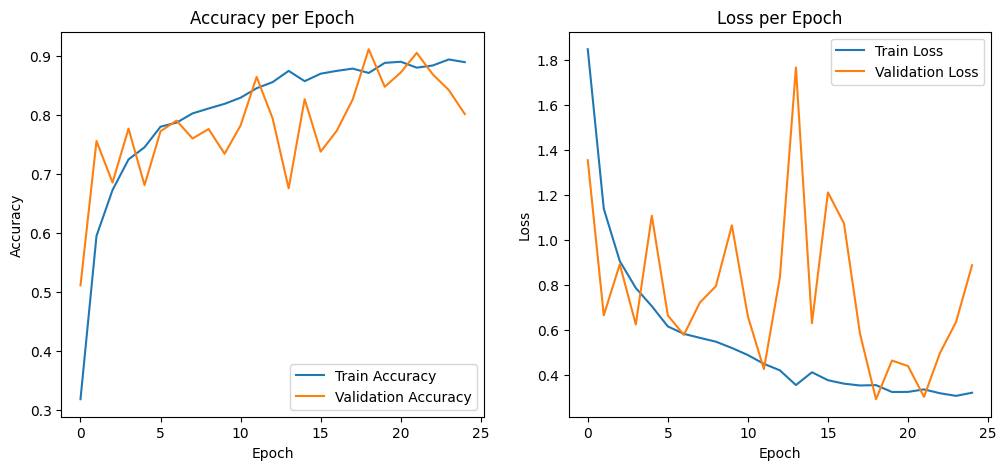

In [ ]:
plt.figure(figsize=(12,5))

# Accuracy
plt.subplot(1,2,1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Accuracy per Epoch')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

# Loss
plt.subplot(1,2,2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Loss per Epoch')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.show()


In [ ]:
test_loss, test_accuracy = model.evaluate(test_generator)
print(f"Test Accuracy : {test_accuracy * 100:.2f}%")
print(f"Test Loss     : {test_loss:.4f}")

26/26 ━━━━━━━━━━━━━━━━━━━━ 509s 20s/step - accuracy: 0.8503 - loss: 0.6661
Test Accuracy : 79.38%
Test Loss     : 1.0284


# Evaluation

26/26 ━━━━━━━━━━━━━━━━━━━━ 4s 134ms/step


<Figure size 800x800 with 0 Axes>

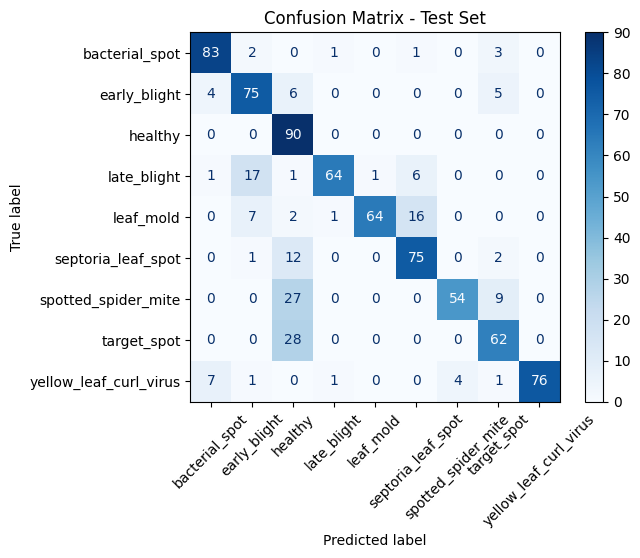

In [ ]:
y_pred = model.predict(test_generator)
y_pred_classes = np.argmax(y_pred, axis=1)
y_true = test_generator.classes

cm = confusion_matrix(y_true, y_pred_classes)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=test_generator.class_indices.keys()
)

plt.figure(figsize=(8,8))
disp.plot(cmap='Blues', xticks_rotation=45)
plt.title("Confusion Matrix - Test Set")
plt.show()


In [ ]:
report = classification_report(
    y_true,
    y_pred_classes,
    target_names=test_generator.class_indices.keys()
)

print("Classification Report:\n")
print(report)

Classification Report:

                        precision    recall  f1-score   support

        bacterial_spot       0.87      0.92      0.90        90
          early_blight       0.73      0.83      0.78        90
               healthy       0.54      1.00      0.70        90
           late_blight       0.96      0.71      0.82        90
             leaf_mold       0.98      0.71      0.83        90
    septoria_leaf_spot       0.77      0.83      0.80        90
   spotted_spider_mite       0.93      0.60      0.73        90
           target_spot       0.76      0.69      0.72        90
yellow_leaf_curl_virus       1.00      0.84      0.92        90

              accuracy                           0.79       810
             macro avg       0.84      0.79      0.80       810
          weighted avg       0.84      0.79      0.80       810



# Saving Model

In [ ]:
model.save("/content/drive/MyDrive/ModelAI_DesaSengka/model_cnn_penyakit_daun_testset.h5")